In [1]:
import pandas as pd

df = pd.read_parquet('0000.parquet')

print(df.head())
print(df.columns)

                                               image  \
0  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...   
1  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...   
2  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...   
3  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...   
4  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...   

                                        ground_truth  
0  {"gt_parse": {"text_sequence": "3 위 에 올 랐 다.타 ...  
1  {"gt_parse": {"text_sequence": "9월께 소련 의 탄압을 피...  
2  {"gt_parse": {"text_sequence": "an의 분류에 따라 이타성...  
3  {"gt_parse": {"text_sequence": "적인 자질이 있었다. 반면...  
4  {"gt_parse": {"text_sequence": "클래식 영화로 간주 되며,...  
Index(['image', 'ground_truth'], dtype='object')


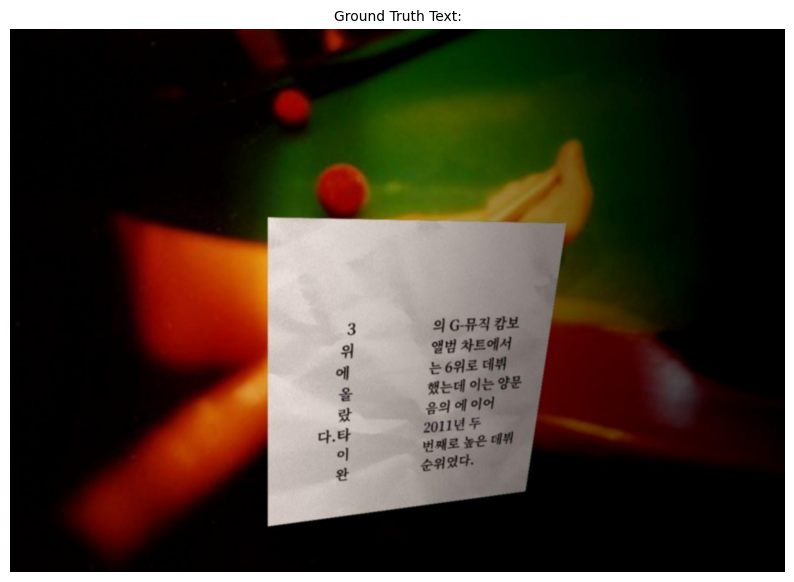

Ground Truth Text:
3 위 에 올 랐 다.타 이 완 의 G-뮤직 캄보 앨범 차트에서 는 6위로 데뷔 했는데 이는 양문 음의 에 이어 2011년 두 번째로 높은 데뷔 순위였다.


In [2]:
import matplotlib.pyplot as plt
from PIL import Image
import io
import json

row = df.iloc[0]

img_bytes = row['image']['bytes']
img = Image.open(io.BytesIO(img_bytes))

gt = json.loads(row['ground_truth'])
text = gt['gt_parse']['text_sequence']

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')
plt.title('Ground Truth Text:', fontsize=10)
plt.show()

print("Ground Truth Text:")
print(text)

In [ ]:
from transformers import DonutProcessor, VisionEncoderDecoderModel
from PIL import Image
import torch
import io
import json

# Force CPU - MPS keeps running out of memory for Donut model
# (your Mac's 20GB GPU memory isn't enough for this 200M parameter model during training)
device = "cpu"
print(f"Using device: {device}")
print("Note: CPU training is slower but won't run out of memory")

# Load pre-trained Donut model
print("\nLoading Donut model and processor...")
processor = DonutProcessor.from_pretrained("naver-clova-ix/donut-base")
model = VisionEncoderDecoderModel.from_pretrained("naver-clova-ix/donut-base")

print(f"Model loaded: {model.__class__.__name__}")
print(f"Encoder: {model.encoder.__class__.__name__}")
print(f"Decoder: {model.decoder.__class__.__name__}")

# Get the expected input size from the processor
image_processor = processor.image_processor
image_size = image_processor.size
if isinstance(image_size, dict):
    expected_height = image_size.get('height', 1280)
    expected_width = image_size.get('width', 960)
else:
    expected_height = expected_width = image_size
print(f"Expected input size: {expected_height}x{expected_width}")

# Configure special tokens
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.decoder_start_token_id = processor.tokenizer.convert_tokens_to_ids(['<s>'])[0]
model.config.eos_token_id = processor.tokenizer.eos_token_id

# Set generation config
model.generation_config.max_length = 512
model.generation_config.decoder_start_token_id = model.config.decoder_start_token_id
model.generation_config.pad_token_id = model.config.pad_token_id
model.generation_config.eos_token_id = model.config.eos_token_id

# Enable gradient checkpointing to save memory
model.config.use_cache = False
model.gradient_checkpointing_enable()
print("✓ Gradient checkpointing enabled")

# Move model to CPU
model.to(device)
print(f"✓ Model moved to {device}")

# Print model size
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel Statistics:")
print(f"  Total parameters: {total_params:,} ({total_params/1e6:.2f}M)")
print(f"  Trainable parameters: {trainable_params:,} ({trainable_params/1e6:.2f}M)")

print("\n✓ Ready for training!")

Using device: cpu
Note: CPU training is slower but won't run out of memory

Loading Donut model and processor...


Loading weights: 100%|██████████| 484/484 [00:00<00:00, 1945.07it/s, Materializing param=encoder.encoder.layers.3.blocks.1.output.dense.weight]                         
The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model loaded: VisionEncoderDecoderModel
Encoder: DonutSwinModel
Decoder: MBartForCausalLM
Expected input size: 2560x1920
✓ Gradient checkpointing enabled
✓ Model moved to cpu

Model Statistics:
  Total parameters: 260,757,624 (260.76M)
  Trainable parameters: 260,757,624 (260.76M)

✓ Ready for training!


In [15]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torchvision import transforms
import torch
from PIL import Image
import io
import json
import re

class DocumentOCRDataset(Dataset):
    def __init__(self, dataframe, processor, max_length=512, augment=False, cache_images=False):
        self.df = dataframe
        self.processor = processor
        self.max_length = max_length
        self.augment = augment
        self.cache_images = cache_images
        self.image_cache = {}  # Initialize cache dictionary
        
        if augment:
            self.augmentation = transforms.Compose([
                transforms.RandomRotation(degrees=2),
                transforms.ColorJitter(brightness=0.2, contrast=0.2),
                transforms.RandomAffine(degrees=0, translate=(0.02, 0.02)),
            ])
        
        # Pre-cache images if requested
        if cache_images:
            print(f"Pre-loading {len(self.df)} images into memory...")
            for idx in range(len(self.df)):
                self._load_image(idx)
            print("Image caching complete!")
    
    def _load_image(self, idx):
        """Load image from cache or dataframe"""
        if idx in self.image_cache:
            return self.image_cache[idx]
        
        row = self.df.iloc[idx]
        img_bytes = row['image']['bytes']
        image = Image.open(io.BytesIO(img_bytes)).convert("RGB")
        
        if self.cache_images:
            self.image_cache[idx] = image
        
        return image
    
    def clean_text(self, text):
        """Clean and normalize text"""
        # Remove excessive whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        return text
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        try:
            row = self.df.iloc[idx]
            
            # Validate image data exists
            if 'image' not in row or 'bytes' not in row['image']:
                raise ValueError(f"Missing image data at index {idx}")
            
            # Load image using helper method
            image = self._load_image(idx)
            
            # Validate image loaded correctly
            if image.size[0] == 0 or image.size[1] == 0:
                raise ValueError(f"Invalid image dimensions at index {idx}")
            
            # Apply augmentation if enabled (only for training)
            if self.augment:
                image = self.augmentation(image)
            
            # Get and validate ground truth
            if 'ground_truth' not in row:
                raise ValueError(f"Missing ground_truth at index {idx}")
                
            gt = json.loads(row['ground_truth'])
            text = gt['gt_parse']['text_sequence']
            
            # Handle empty text
            if not text or not text.strip():
                text = " "  # Use space instead of empty string
            
            # Clean text
            text = self.clean_text(text)
            
            # Process image
            pixel_values = self.processor(
                image, 
                return_tensors="pt"
            ).pixel_values.squeeze()
            
            # Process text (labels)
            labels = self.processor.tokenizer(
                text, 
                add_special_tokens=False, 
                max_length=self.max_length,
                padding="max_length",
                truncation=True,
                return_tensors="pt"
            ).input_ids.squeeze()
            
            # Replace padding token id with -100 for loss calculation
            labels[labels == self.processor.tokenizer.pad_token_id] = -100
            
            return {
                "pixel_values": pixel_values, 
                "labels": labels,
                "idx": idx,  # For debugging
                "text_length": (labels != -100).sum().item(),  # Actual text length
            }
            
        except Exception as e:
            print(f"Error loading sample {idx}: {e}")
            raise

# Custom collate function for batching
def collate_fn(batch):
    """Collate function to handle batching"""
    pixel_values = torch.stack([item['pixel_values'] for item in batch])
    labels = torch.stack([item['labels'] for item in batch])
    
    return {
        'pixel_values': pixel_values,
        'labels': labels,
        'idx': [item['idx'] for item in batch],
        'text_length': [item['text_length'] for item in batch]
    }

# Use smaller subset for faster CPU training
df_subset = df.sample(n=500, random_state=42).reset_index(drop=True)
print(f"Using {len(df_subset)} samples for faster training")

# Optional: Create length-based stratification for better split
df_subset['text_length'] = df_subset['ground_truth'].apply(
    lambda x: len(json.loads(x)['gt_parse']['text_sequence'])
)
df_subset['text_length_bin'] = pd.cut(
    df_subset['text_length'],
    bins=5,
    labels=False,
    duplicates='drop'
)

# Split data into train and validation with stratification
train_df, val_df = train_test_split(
    df_subset, 
    test_size=0.1, 
    random_state=42,
    stratify=df_subset['text_length_bin'] if len(df_subset) > 50 else None
)
print(f"Train samples: {len(train_df)}, Validation samples: {len(val_df)}")

# Create datasets
# Enable augmentation for training, disable for validation
train_dataset = DocumentOCRDataset(
    train_df.reset_index(drop=True), 
    processor, 
    augment=True,  # Apply augmentation to training data
    cache_images=False  # Set to True if you have enough RAM
)

val_dataset = DocumentOCRDataset(
    val_df.reset_index(drop=True), 
    processor,
    augment=False,  # No augmentation for validation
    cache_images=False
)

# Use num_workers=0 for Jupyter notebooks (multiprocessing doesn't work well)
num_workers = 0

# Create DataLoaders with optimized settings
train_loader = DataLoader(
    train_dataset, 
    batch_size=8,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=False,  # MPS doesn't support pin_memory
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=8,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=False,
    collate_fn=collate_fn,
)

print(f"Train batches: {len(train_loader)}, Validation batches: {len(val_loader)}")

# Test loading a batch
print("\nTesting data loading...")
try:
    batch = next(iter(train_loader))
    print(f"Batch pixel_values shape: {batch['pixel_values'].shape}")
    print(f"Batch labels shape: {batch['labels'].shape}")
    print(f"Text lengths in batch: {batch['text_length']}")
    print("✓ Data loading successful!")
except Exception as e:
    print(f"✗ Error loading batch: {e}")

# Optional: Get dataset statistics
def get_dataset_stats(dataset):
    """Print statistics about the dataset"""
    text_lengths = []
    
    print(f"\nAnalyzing {len(dataset)} samples...")
    for idx in range(min(len(dataset), 100)):  # Sample first 100
        try:
            item = dataset[idx]
            text_lengths.append(item['text_length'])
        except Exception as e:
            print(f"Error at index {idx}: {e}")
    
    if text_lengths:
        import numpy as np
        print(f"Text length statistics:")
        print(f"  Mean: {np.mean(text_lengths):.2f}")
        print(f"  Median: {np.median(text_lengths):.2f}")
        print(f"  Max: {np.max(text_lengths)}")
        print(f"  Min: {np.min(text_lengths)}")
        print(f"  Std: {np.std(text_lengths):.2f}")

# Run statistics
get_dataset_stats(train_dataset)

Using 500 samples for faster training
Train samples: 450, Validation samples: 50
Train batches: 57, Validation batches: 7

Testing data loading...
Batch pixel_values shape: torch.Size([8, 3, 2560, 1920])
Batch labels shape: torch.Size([8, 512])
Text lengths in batch: [61, 130, 55, 53, 54, 136, 82, 69]
✓ Data loading successful!

Analyzing 450 samples...
Text length statistics:
  Mean: 132.34
  Median: 119.00
  Max: 512
  Min: 29
  Std: 81.10


In [16]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, EarlyStoppingCallback
from transformers.trainer_callback import TrainerCallback
import torch
import numpy as np
import time
import os

# Custom callback for better monitoring
class ProgressCallback(TrainerCallback):
    def __init__(self):
        self.training_start_time = None
        self.epoch_start_time = None
        
    def on_train_begin(self, args, state, control, **kwargs):
        self.training_start_time = time.time()
        print("\n" + "="*50)
        print("Training Started!")
        print("="*50)
        
    def on_epoch_begin(self, args, state, control, **kwargs):
        self.epoch_start_time = time.time()
        print(f"\n--- Epoch {int(state.epoch) + 1}/{int(args.num_train_epochs)} ---")
        
    def on_epoch_end(self, args, state, control, **kwargs):
        epoch_time = time.time() - self.epoch_start_time
        print(f"Epoch {int(state.epoch)} completed in {epoch_time/60:.2f} minutes")
        
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            if 'loss' in logs:
                print(f"Step {state.global_step}: Loss = {logs['loss']:.4f}")
            if 'eval_loss' in logs:
                print(f"Validation Loss = {logs['eval_loss']:.4f}")
                
    def on_train_end(self, args, state, control, **kwargs):
        total_time = time.time() - self.training_start_time
        print("\n" + "="*50)
        print(f"Training Completed in {total_time/60:.2f} minutes!")
        print("="*50)

# Data collator
def collate_fn(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels = torch.stack([item["labels"] for item in batch])
    return {"pixel_values": pixel_values, "labels": labels}

# CPU training settings
batch_size = 1
gradient_accum = 8
num_workers = 0

print("CPU Training Configuration:")
print(f"  Batch size: {batch_size}")
print(f"  Gradient accumulation: {gradient_accum}")
print(f"  Effective batch size: {batch_size * gradient_accum}")

# Configure training arguments for CPU
training_args = Seq2SeqTrainingArguments(
    output_dir="./donut-document-ocr",
    save_total_limit=2,
    save_steps=100,
    save_strategy="steps",
    
    num_train_epochs=1,  # Start with 1 epoch to test
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    gradient_accumulation_steps=gradient_accum,
    
    learning_rate=3e-5,
    weight_decay=0.01,
    warmup_steps=50,
    max_grad_norm=1.0,
    lr_scheduler_type="cosine",
    
    eval_strategy="steps",
    eval_steps=100,
    
    predict_with_generate=False,  # Disable for faster training
    
    logging_dir="./logs",
    logging_steps=20,
    
    dataloader_num_workers=num_workers,
    dataloader_pin_memory=False,
    fp16=False,
    
    report_to="none",
    push_to_hub=False,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    
    gradient_checkpointing=True,
    optim="adamw_torch",
    
    seed=42,
)

# Calculate steps
steps_per_epoch = len(train_dataset) // (batch_size * gradient_accum)
total_steps = steps_per_epoch * training_args.num_train_epochs
print(f"\nEstimated {total_steps} total steps ({steps_per_epoch} per epoch)")
print(f"CPU training estimated time: {total_steps * 3 / 60:.1f} - {total_steps * 6 / 60:.1f} minutes")

# Create callbacks
callbacks = [
    ProgressCallback(),
    EarlyStoppingCallback(early_stopping_patience=5, early_stopping_threshold=0.001)
]

# Create trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collate_fn,
    callbacks=callbacks,
)

print("\n" + "="*50)
print("Trainer initialized successfully!")
print("="*50)

# Check for existing checkpoints
resume_from = None
if os.path.exists(training_args.output_dir):
    checkpoints = [d for d in os.listdir(training_args.output_dir) if d.startswith("checkpoint-")]
    if checkpoints:
        latest = max(checkpoints, key=lambda x: int(x.split("-")[1]))
        resume_from = os.path.join(training_args.output_dir, latest)
        print(f"\nFound checkpoint: {resume_from}")

print(f"\nTraining {len(train_dataset)} samples, validating on {len(val_dataset)} samples")
print("\n✓ Ready! Run the next cell to start training.")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


CPU Training Configuration:
  Batch size: 1
  Gradient accumulation: 8
  Effective batch size: 8

Estimated 56 total steps (56 per epoch)
CPU training estimated time: 2.8 - 5.6 minutes

Trainer initialized successfully!

Training 450 samples, validating on 50 samples

✓ Ready! Run the next cell to start training.


In [ ]:
# Clear any GPU memory and force CPU
import torch
import gc

# Clear GPU cache
if torch.backends.mps.is_available():
    torch.mps.empty_cache()
gc.collect()

# Make sure model is on CPU
model.to("cpu")
device = "cpu"

print(f"Model device: {next(model.parameters()).device}")
print("Starting training on CPU...")
print("This may take 30-60 minutes depending on your CPU speed.")
print("Watch the loss values - they should decrease over time.\n")

trainer.train()

Model device: cpu
Starting training on CPU...
This may take 30-60 minutes depending on your CPU speed.
Watch the loss values - they should decrease over time.


Training Started!

--- Epoch 1/1 ---


Step,Training Loss,Validation Loss


Step 20: Loss = 13.2702


In [1]:
# Function to monitor training progress
def monitor_training(trainer, check_interval=300):
    """Monitor training progress and resource usage"""
    import psutil
    
    print("\nTraining Monitor Started (updates every 5 minutes)")
    print("-" * 50)
    
    while trainer.state.global_step < trainer.state.max_steps:
        time.sleep(check_interval)
        
        # Get current metrics
        step = trainer.state.global_step
        loss = trainer.state.log_history[-1].get('loss', 'N/A') if trainer.state.log_history else 'N/A'
        
        # Get resource usage
        cpu_percent = psutil.cpu_percent()
        memory = psutil.virtual_memory()
        
        print(f"\n[{time.strftime('%H:%M:%S')}] Step {step}")
        print(f"  Loss: {loss}")
        print(f"  CPU: {cpu_percent}%")
        print(f"  RAM: {memory.percent}% ({memory.used / 1e9:.1f}GB / {memory.total / 1e9:.1f}GB)")
        
        if device == "cuda":
            print(f"  GPU Memory: {torch.cuda.memory_allocated() / 1e9:.2f}GB")

# Function to save training results
def save_training_summary(trainer, output_file="training_summary.txt"):
    """Save training summary to file"""
    with open(output_file, 'w') as f:
        f.write("Training Summary\n")
        f.write("=" * 50 + "\n\n")
        f.write(f"Total steps: {trainer.state.global_step}\n")
        f.write(f"Total epochs: {trainer.state.epoch}\n")
        f.write(f"Best metric: {trainer.state.best_metric}\n")
        f.write(f"Best checkpoint: {trainer.state.best_model_checkpoint}\n\n")
        
        f.write("Training History:\n")
        f.write("-" * 50 + "\n")
        for log in trainer.state.log_history:
            f.write(f"{log}\n")
    
    print(f"Training summary saved to {output_file}")

In [ ]:
# ============================================================================
# COMPLETE DONUT OCR FINE-TUNING SCRIPT - OPTIMIZED FOR CPU
# ============================================================================

from transformers import DonutProcessor, VisionEncoderDecoderModel
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, EarlyStoppingCallback
from transformers.trainer_callback import TrainerCallback
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torchvision import transforms
from PIL import Image
import torch
import pandas as pd
import numpy as np
import io
import json
import re
import time
import os

print("="*70)
print("DONUT OCR FINE-TUNING - OPTIMIZED VERSION")
print("="*70)

# ============================================================================
# STEP 0: LOAD PARQUET FILE
# ============================================================================

print("\n📁 Loading parquet file...")

# Load your parquet file
# Replace with your actual parquet file path
parquet_file = "0000.parquet"  # ← CHANGE THIS

# Option 1: If you know the exact path
try:
    df = pd.read_parquet(parquet_file)
    print(f"✓ Loaded {len(df)} samples from {parquet_file}")
except FileNotFoundError:
    print(f"❌ File not found: {parquet_file}")
    print("\nPlease provide the correct path to your .parquet file")
    print("\nCommon locations:")
    print("  • Current directory: './data.parquet'")
    print("  • Downloads: '~/Downloads/data.parquet'")
    print("  • HF cache: '~/.cache/huggingface/datasets/...'")
    
    # Try to find parquet files
    import glob
    found = glob.glob("**/*.parquet", recursive=True)
    if found:
        print(f"\nFound these .parquet files:")
        for f in found[:5]:
            print(f"  • {f}")
    raise

# Verify structure
print("\n📋 Dataset info:")
print(f"  Columns: {list(df.columns)}")
print(f"  Shape: {df.shape}")
print(f"  Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

# ============================================================================
# STEP 1: MODEL LOADING
# ============================================================================

device = "cpu"
print(f"\n📱 Using device: {device}")
print("Note: CPU training is slower but stable\n")

print("Loading Donut model and processor...")
processor = DonutProcessor.from_pretrained("naver-clova-ix/donut-base")
model = VisionEncoderDecoderModel.from_pretrained("naver-clova-ix/donut-base")

print(f"✓ Model loaded: {model.__class__.__name__}")
print(f"  Encoder: {model.encoder.__class__.__name__}")
print(f"  Decoder: {model.decoder.__class__.__name__}")

# Get expected input size
image_processor = processor.image_processor
image_size = image_processor.size
if isinstance(image_size, dict):
    expected_height = image_size.get('height', 1280)
    expected_width = image_size.get('width', 960)
else:
    expected_height = expected_width = image_size
print(f"  Expected input size: {expected_height}x{expected_width}")

# ============================================================================
# STEP 2: FREEZE ENCODER (Critical optimization!)
# ============================================================================

print("\n🔒 Freezing encoder...")
for param in model.encoder.parameters():
    param.requires_grad = False

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"✓ Encoder frozen!")
print(f"  Total parameters: {total_params:,} ({total_params/1e6:.2f}M)")
print(f"  Trainable parameters: {trainable_params:,} ({trainable_params/1e6:.2f}M)")
print(f"  Frozen: {(frozen_params/total_params)*100:.1f}%")
print(f"  Speed improvement: ~{total_params/trainable_params:.1f}x faster")

# ============================================================================
# STEP 3: ANALYZE DATA FOR OPTIMAL MAX_LENGTH
# ============================================================================

print("\n📊 Analyzing dataset to optimize max_length...")

# Sample data for analysis
df_analysis = df.sample(n=min(1000, len(df)), random_state=42)
text_lengths = df_analysis['ground_truth'].apply(
    lambda x: len(json.loads(x)['gt_parse']['text_sequence'])
)

max_95th = int(text_lengths.quantile(0.95))
optimal_max_length = min(256, max_95th + 50)

print(f"  Mean length: {text_lengths.mean():.1f}")
print(f"  Median: {text_lengths.median():.1f}")
print(f"  95th percentile: {max_95th}")
print(f"  Max: {text_lengths.max()}")
print(f"✓ Using max_length: {optimal_max_length}")

# ============================================================================
# STEP 4: CONFIGURE MODEL
# ============================================================================

print("\n⚙️  Configuring model...")

# Special tokens
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.decoder_start_token_id = processor.tokenizer.convert_tokens_to_ids(['<s>'])[0]
model.config.eos_token_id = processor.tokenizer.eos_token_id

model.generation_config.max_length = optimal_max_length
model.generation_config.num_beams = 1
model.generation_config.early_stopping = False
model.generation_config.no_repeat_ngram_size = 3
model.generation_config.length_penalty = 1.0
model.generation_config.repetition_penalty = 1.2
model.generation_config.decoder_start_token_id = model.config.decoder_start_token_id
model.generation_config.pad_token_id = model.config.pad_token_id
model.generation_config.eos_token_id = model.config.eos_token_id
model.generation_config.forced_bos_token_id = None

# Gradient checkpointing
model.config.use_cache = False
model.gradient_checkpointing_enable()

# Move to device
model.to(device)


print("✓ Model configured")
print(f"  Vocabulary size: {len(processor.tokenizer)}")
print(f"  PAD token ID: {processor.tokenizer.pad_token_id}")
print(f"  EOS token ID: {processor.tokenizer.eos_token_id}")
print(f"  Max length: {optimal_max_length}")

# ============================================================================
# STEP 5: DATASET CLASS
# ============================================================================

class DocumentOCRDataset(Dataset):
    def __init__(self, dataframe, processor, max_length=256, augment=False, 
                 cache_images=True, max_cache_size=200, task_name="document-ocr"):
        self.df = dataframe
        self.processor = processor
        self.max_length = max_length
        self.augment = augment
        self.max_cache_size = max_cache_size if cache_images else 0
        self.image_cache = {}
        self.task_name = task_name
        self.task_prompt = f"<s_{task_name}>"
        
        if augment:
            self.augmentation = transforms.Compose([
                transforms.RandomRotation(degrees=2),
                transforms.ColorJitter(brightness=0.2, contrast=0.2),
                transforms.RandomAffine(degrees=0, translate=(0.02, 0.02)),
            ])
        
        # Cache images
        if self.max_cache_size > 0:
            print(f"  Caching up to {self.max_cache_size} images...")
            for idx in range(min(len(self.df), self.max_cache_size)):
                self._load_image(idx)
            print(f"  ✓ Cached {len(self.image_cache)} images")
    
    def _load_image(self, idx):
        if idx in self.image_cache:
            return self.image_cache[idx]
        
        row = self.df.iloc[idx]
        img_bytes = row['image']['bytes']
        image = Image.open(io.BytesIO(img_bytes)).convert("RGB")
        
        if len(self.image_cache) < self.max_cache_size:
            self.image_cache[idx] = image
        
        return image
    
    def clean_text(self, text):
        return re.sub(r'\s+', ' ', text).strip()
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        try:
            row = self.df.iloc[idx]
            
            # Load image
            if 'image' not in row or 'bytes' not in row['image']:
                raise ValueError(f"Missing image data at index {idx}")
            
            image = self._load_image(idx)
            
            if image.size[0] == 0 or image.size[1] == 0:
                raise ValueError(f"Invalid image dimensions at index {idx}")
            
            if self.augment:
                image = self.augmentation(image)
            
            # Get text
            if 'ground_truth' not in row:
                raise ValueError(f"Missing ground_truth at index {idx}")
                
            gt = json.loads(row['ground_truth'])
            text = gt['gt_parse']['text_sequence']
            
            if not text or not text.strip():
                text = " "
            
            text = self.clean_text(text)
            
            # Add task prompt
            text_with_task = f"{self.task_prompt} {text}"
            
            # Process
            pixel_values = self.processor(image, return_tensors="pt").pixel_values.squeeze()
            
            labels = self.processor.tokenizer(
                text_with_task,
                add_special_tokens=True,
                max_length=self.max_length,
                padding="max_length",
                truncation=True,
                return_tensors="pt"
            ).input_ids.squeeze()
            
            # Mask padding
            labels[labels == self.processor.tokenizer.pad_token_id] = -100
            
            return {
                "pixel_values": pixel_values, 
                "labels": labels,
                "idx": idx,
                "text_length": (labels != -100).sum().item(),
            }
            
        except Exception as e:
            print(f"Error loading sample {idx}: {e}")
            raise

# ============================================================================
# STEP 6: COMPUTE METRICS
# ============================================================================

def compute_metrics(eval_pred):
    """Compute Character Error Rate"""
    predictions, labels = eval_pred
    
    if isinstance(predictions, tuple):
        predictions = predictions[0]
    
    labels = np.where(labels != -100, labels, processor.tokenizer.pad_token_id)
    
    decoded_preds = processor.tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = processor.tokenizer.batch_decode(labels, skip_special_tokens=True)
    
    # Simple character accuracy
    total_chars = sum(len(label) for label in decoded_labels)
    correct_chars = sum(
        sum(1 for p, l in zip(pred, label) if p == l)
        for pred, label in zip(decoded_preds, decoded_labels)
    )
    cer_score = 1 - (correct_chars / max(total_chars, 1))
    
    return {
        "cer": cer_score,
        "avg_pred_length": np.mean([len(p) for p in decoded_preds]),
    }

# ============================================================================
# STEP 7: PREPARE DATA
# ============================================================================

print("\n📦 Preparing dataset...")

# Sample subset
n_samples = 150  # Adjust for your needs
df_subset = df.sample(n=min(n_samples, len(df)), random_state=42).reset_index(drop=True)
print(f"  Using {len(df_subset)} samples")

# Stratification
df_subset['text_length'] = df_subset['ground_truth'].apply(
    lambda x: len(json.loads(x)['gt_parse']['text_sequence'])
)
df_subset['text_length_bin'] = pd.cut(
    df_subset['text_length'],
    bins=min(5, len(df_subset)//10),
    labels=False,
    duplicates='drop'
)

# Split
train_df, val_df = train_test_split(
    df_subset, 
    test_size=0.15, 
    random_state=42,
    stratify=df_subset['text_length_bin'] if len(df_subset) > 30 else None
)
print(f"  Train: {len(train_df)}, Val: {len(val_df)}")

# Create datasets
print("\n  Creating training dataset...")
train_dataset = DocumentOCRDataset(
    train_df.reset_index(drop=True), 
    processor, 
    max_length=optimal_max_length,
    augment=False,
    cache_images=True,
    max_cache_size=200,
    task_name="document-ocr"
)

print("\n  Creating validation dataset...")
val_dataset = DocumentOCRDataset(
    val_df.reset_index(drop=True), 
    processor,
    max_length=optimal_max_length,
    augment=False,
    cache_images=True,
    max_cache_size=50,
    task_name="document-ocr"
)

# Collate function
def collate_fn(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels = torch.stack([item["labels"] for item in batch])
    return {"pixel_values": pixel_values, "labels": labels}

# Test data loading
print("\n  Testing data loading...")
test_batch = train_dataset[0]
print(f"  ✓ Pixel values shape: {test_batch['pixel_values'].shape}")
print(f"  ✓ Labels shape: {test_batch['labels'].shape}")
print(f"  ✓ Text length: {test_batch['text_length']}")

# ============================================================================
# STEP 8: TRAINING SETUP
# ============================================================================

print("\n🎯 Setting up training...")

class ProgressCallback(TrainerCallback):
    def __init__(self):
        self.training_start_time = None
        self.epoch_start_time = None
        
    def on_train_begin(self, args, state, control, **kwargs):
        self.training_start_time = time.time()
        print("\n" + "="*70)
        print("TRAINING STARTED")
        print("="*70)
        
    def on_epoch_begin(self, args, state, control, **kwargs):
        self.epoch_start_time = time.time()
        print(f"\n{'='*70}")
        print(f"Epoch {int(state.epoch) + 1}/{int(args.num_train_epochs)}")
        print(f"{'='*70}")
        
    def on_epoch_end(self, args, state, control, **kwargs):
        epoch_time = time.time() - self.epoch_start_time
        print(f"\n✓ Epoch completed in {epoch_time/60:.2f} minutes")
        
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            if 'loss' in logs:
                print(f"  Step {state.global_step}: Loss = {logs['loss']:.4f}")
            if 'eval_loss' in logs:
                print(f"  Val Loss = {logs['eval_loss']:.4f}")
            if 'cer' in logs:
                print(f"  CER = {logs['cer']:.4f}")
                
    def on_train_end(self, args, state, control, **kwargs):
        total_time = time.time() - self.training_start_time
        print("\n" + "="*70)
        print(f"TRAINING COMPLETED in {total_time/60:.2f} minutes")
        print("="*70)

# Training configuration
batch_size = 1
gradient_accum = 16
num_epochs = 10

print(f"  Batch size: {batch_size}")
print(f"  Gradient accumulation: {gradient_accum}")
print(f"  Effective batch size: {batch_size * gradient_accum}")
print(f"  Epochs: {num_epochs}")

training_args = Seq2SeqTrainingArguments(
    output_dir="./donut-ocr-decoder-only",
    save_total_limit=2,
    save_steps=50,
    save_strategy="steps",
    
    generation_config=model.generation_config,
    
    num_train_epochs=num_epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    gradient_accumulation_steps=gradient_accum,
    
    learning_rate=1e-4,
    weight_decay=0.01,
    warmup_steps=30,
    max_grad_norm=1.0,
    lr_scheduler_type="cosine",
    
    eval_strategy="steps",
    eval_steps=50,
    eval_accumulation_steps=1,
    
    predict_with_generate=True,
    generation_max_length=optimal_max_length,
    generation_num_beams=1,
    
    logging_dir="./logs",
    logging_steps=10,
    logging_first_step=True,
    logging_strategy="steps",
    
    dataloader_num_workers=0,
    dataloader_pin_memory=False,
    fp16=False,
    
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    
    gradient_checkpointing=True,
    optim="adamw_torch",
    
    report_to="none",
    push_to_hub=False,
    seed=42,
    data_seed=42,
)

# Estimate time
steps_per_epoch = len(train_dataset) // (batch_size * gradient_accum)
total_steps = steps_per_epoch * num_epochs

print(f"\n  Estimated steps: {total_steps}")
print(f"  Estimated time: {total_steps * 2 / 60:.1f}-{total_steps * 4 / 60:.1f} minutes")

# Create trainer
callbacks = [
    ProgressCallback(),
    EarlyStoppingCallback(early_stopping_patience=3, early_stopping_threshold=0.01)
]

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    callbacks=callbacks,
)

# Check for checkpoints
resume_from = None
if os.path.exists(training_args.output_dir):
    checkpoints = [d for d in os.listdir(training_args.output_dir) 
                   if d.startswith("checkpoint-")]
    if checkpoints:
        latest = max(checkpoints, key=lambda x: int(x.split("-")[1]))
        resume_from = os.path.join(training_args.output_dir, latest)
        print(f"\n⚠️  Found checkpoint: {resume_from}")

# ============================================================================
# READY TO TRAIN
# ============================================================================

print("\n" + "="*70)
print("✅ SETUP COMPLETE - READY TO TRAIN")
print("="*70)

print(f"\n📊 Summary:")
print(f"  • Device: {device}")
print(f"  • Training samples: {len(train_dataset)}")
print(f"  • Validation samples: {len(val_dataset)}")
print(f"  • Trainable params: {trainable_params/1e6:.1f}M")
print(f"  • Max sequence length: {optimal_max_length}")
print(f"  • Effective batch size: {batch_size * gradient_accum}")
print(f"  • Total training steps: {total_steps}")

print(f"\n🚀 To start training:")
print(f"   >>> trainer.train()")

print(f"\n💾 To save model after training:")
print(f"   >>> trainer.save_model('./donut-ocr-final')")
print(f"   >>> processor.save_pretrained('./donut-ocr-final')")

print(f"\n📈 To evaluate:")
print(f"   >>> trainer.evaluate()")

if resume_from:
    print(f"\n⏯️  To resume from checkpoint:")
    print(f"   >>> trainer.train(resume_from_checkpoint='{resume_from}')")

print("\n" + "="*70)

trainer.train()

trainer.save_model('./donut-ocr-final')
processor.save_pretrained('./donut-ocr-final')
trainer.evaluate()

DONUT OCR FINE-TUNING - OPTIMIZED VERSION

📁 Loading parquet file...
✓ Loaded 11766 samples from 0000.parquet

📋 Dataset info:
  Columns: ['image', 'ground_truth']
  Shape: (11766, 2)
  Memory usage: 9.56 MB

📱 Using device: cpu
Note: CPU training is slower but stable

Loading Donut model and processor...


Loading weights: 100%|██████████| 484/484 [00:00<00:00, 1989.22it/s, Materializing param=encoder.encoder.layers.3.blocks.1.output.dense.weight]                         
The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✓ Model loaded: VisionEncoderDecoderModel
  Encoder: DonutSwinModel
  Decoder: MBartForCausalLM
  Expected input size: 2560x1920

🔒 Freezing encoder...
✓ Encoder frozen!
  Total parameters: 260,757,624 (260.76M)
  Trainable parameters: 186,576,896 (186.58M)
  Frozen: 28.4%
  Speed improvement: ~1.4x faster

📊 Analyzing dataset to optimize max_length...
  Mean length: 231.0
  Median: 199.0
  95th percentile: 511
  Max: 941
✓ Using max_length: 256

⚙️  Configuring model...
✓ Model configured
  Vocabulary size: 57525
  PAD token ID: 1
  EOS token ID: 2
  Max length: 256

📦 Preparing dataset...
  Using 150 samples
  Train: 127, Val: 23

  Creating training dataset...
  Caching up to 200 images...
  ✓ Cached 127 images

  Creating validation dataset...
  Caching up to 50 images...
  ✓ Cached 23 images

  Testing data loading...
  ✓ Pixel values shape: torch.Size([3, 2560, 1920])
  ✓ Labels shape: torch.Size([256])
  ✓ Text length: 256

🎯 Setting up training...
  Batch size: 1
  Gradient acc

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



  Estimated steps: 70
  Estimated time: 2.3-4.7 minutes

⚠️  Found checkpoint: ./donut-ocr-decoder-only/checkpoint-16

✅ SETUP COMPLETE - READY TO TRAIN

📊 Summary:
  • Device: cpu
  • Training samples: 127
  • Validation samples: 23
  • Trainable params: 186.6M
  • Max sequence length: 256
  • Effective batch size: 16
  • Total training steps: 70

🚀 To start training:
   >>> trainer.train()

💾 To save model after training:
   >>> trainer.save_model('./donut-ocr-final')
   >>> processor.save_pretrained('./donut-ocr-final')

📈 To evaluate:
   >>> trainer.evaluate()

⏯️  To resume from checkpoint:
   >>> trainer.train(resume_from_checkpoint='./donut-ocr-decoder-only/checkpoint-16')


TRAINING STARTED

Epoch 1/10


Step,Training Loss,Validation Loss


  Step 1: Loss = 36.9742

✓ Epoch completed in 56.59 minutes

Epoch 2/10
  Step 10: Loss = 30.6701

✓ Epoch completed in 60.15 minutes

Epoch 3/10
  Step 20: Loss = 78.9036

✓ Epoch completed in 51.38 minutes

Epoch 4/10
  Step 30: Loss = 187.1977

✓ Epoch completed in 62.60 minutes

Epoch 5/10
  Step 40: Loss = 260.1333

✓ Epoch completed in 62.47 minutes

Epoch 6/10

✓ Epoch completed in 53.71 minutes

Epoch 7/10
  Step 50: Loss = 278.4993
